# ConvNeXt-Base Training Pipeline

Fine-tunes a pretrained ConvNeXt-Base backbone for 3-class chest X-ray classification: `NORMAL`, `BACTERIAL_PNEUMONIA`, and `VIRAL_PNEUMONIA`.

## Training strategy

| Phase | Epochs | Layers trained | Learning rate |
|---|---|---|---|
| 1 — Head warm-up | 1–3 | Classifier head only | `1e-4` |
| 2 — Fine-tuning | 4+ | Head + last 4 feature stages | `1e-5` |

ConvNeXt uses large 7×7 depthwise convolutions within each stage. Partial unfreezing via `model.features[-4:]` is important — fine-tuning the entire network from scratch would overwrite the rich ImageNet representations with too few medical examples.

## Key design decisions
- **Class-weighted loss**: corrects for class imbalance across the three pneumonia types
- **Label smoothing (0.05)**: mild regularisation on logit targets
- **Mixed precision (AMP)**: enabled when CUDA is available
- **Early stopping (patience=4)**: prevents overfitting on this relatively small medical dataset (~5,000 training images)

## Outputs
- `ConvNeXt_pneumonia.pth` — best model weights
- `classes.json` — class index-to-label mapping

In [1]:
# Install this once
!pip install import-ipynb
!pip install import-ipynb scikit-learn

## DataLoader Import

Imports the cleaned datasets and preprocessing transforms from `Preprocessing_Pipeline.ipynb`. This gives us:
- `prep.train_dataset` / `prep.val_dataset` / `prep.test_dataset` — `ImageFolder` datasets after autoencoder-based outlier removal
- `prep.train_dataset.classes` — ordered class name list used to configure the model output layer

The full preprocessing pipeline (CLAHE, noise reduction, normalisation, augmentations) is already embedded in each dataset object. No additional transforms are applied here.

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 31.6839


Class 0 Epoch 2, Total Loss: 18.8980


Class 0 Epoch 3, Total Loss: 17.7581


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.0696


Class 2 Epoch 2, Total Loss: 3.9886


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0775862].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0616211].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0177169].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0696037].


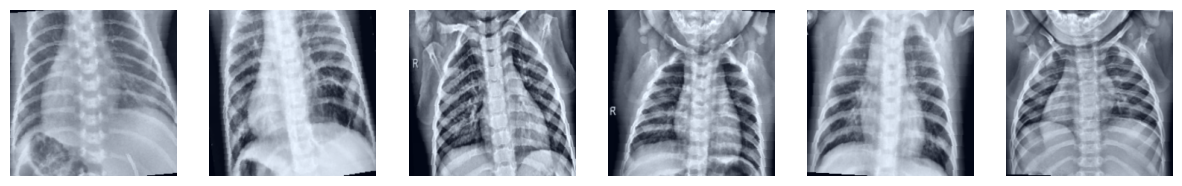

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)


In [2]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [3]:
from torch.utils.data import DataLoader
 
train_loader = DataLoader(prep.train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(prep.val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(prep.test_dataset, batch_size=32, shuffle=False)

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


## ConvNeXt-Base Architecture

ConvNeXt-Base (~89M parameters) is a modernised pure-CNN architecture that incorporates design principles from Vision Transformers: large 7×7 depthwise convolutions, LayerNorm instead of BatchNorm, inverted bottleneck blocks, and GELU activations.

The standard classifier head (`classifier[2]: Linear(in_features → 1000)`) is replaced with:
```
Linear(in_features → num_classes)
```
ConvNeXt's classifier already includes `AdaptiveAvgPool2d + LayerNorm` before the final linear, providing implicit global regularisation before the class logits.

In [5]:
import torch.nn as nn
from torchvision import models

model = models.convnext_base(
    weights=models.ConvNeXt_Base_Weights.DEFAULT
)

model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    len(prep.train_dataset.classes)
)

model = model.to(device)

### Phase 1: Head-Only Training

All backbone parameters are frozen — only the newly added classifier head will receive gradient updates for the first `FREEZE_EPOCHS` epochs. This prevents the randomly-initialised head from destroying pretrained feature representations during early training when its gradients are large and noisy.

In [6]:
# 🔥 Freeze all
for param in model.parameters():
    param.requires_grad = False

# Train classifier first
for param in model.classifier.parameters():
    param.requires_grad = True

In [7]:
from collections import Counter

counts = Counter(prep.train_dataset.targets)
total = sum(counts.values())
class_weights = [total / counts[i] for i in range(len(counts))]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

### Class Weighting

Computes inverse-frequency weights for each class: `weight[i] = total_samples / count[i]`. This means errors on the small `VIRAL_PNEUMONIA` class are penalised proportionally more than errors on the larger `BACTERIAL_PNEUMONIA` class. The weights are passed directly to `CrossEntropyLoss`, making the loss surface reflect clinical priority rather than dataset frequency.

## Training Configuration

| Parameter | Value | Rationale |
|---|---|---|
| Loss function | `CrossEntropyLoss` (weighted) | Class weights inversely proportional to sample count; penalises minority-class errors more heavily |
| Label smoothing | `0.05` | Mild regularisation on logit targets |
| Optimizer | `Adam` | Adaptive per-parameter learning rates; robust without extensive LR tuning |
| Head LR (Phase 1) | `1e-4` | Fast convergence for the new classifier head |
| Fine-tune LR (Phase 2) | `1e-5` | Conservative rate to avoid overwriting ConvNeXt's large-kernel features |
| Weight decay | `1e-4` | L2 regularisation |
| LR scheduler | `ReduceLROnPlateau` | Multiplies LR by 0.3 after 2 epochs without val loss improvement |
| Max epochs | `20` | Upper bound; early stopping typically triggers earlier |
| Freeze epochs | `3` | Epochs before last-4-stage unfreezing |
| Early stop patience | `4` | Epochs to wait before halting training |
| Gradient clipping | `2.0` | Caps global gradient norm to prevent destructive updates from bad batches |

In [8]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.3
)

EPOCHS = 20
FREEZE_EPOCHS = 3
PATIENCE = 4

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = copy.deepcopy(model.state_dict())

# ✅ AMP only if CUDA
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

C:\Users\noora\AppData\Local\Temp\ipykernel_15732\1725517783.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


## Training Loop

`train_one_epoch` runs one full pass over the training set. Key implementation details:

- **Mixed precision** (`torch.cuda.amp.autocast`): forward pass computes in float16 where safe, reducing GPU memory and increasing throughput. `GradScaler` rescales gradients back to float32 before the optimizer step to prevent underflow
- **Gradient clipping** (`clip_grad_norm_=2.0`): caps the global L2 norm of all gradients, preventing a single bad batch from causing a destructive parameter update
- `optimizer.zero_grad()` is called before the forward pass (not after), which is the recommended pattern when using gradient scaling
- Returns average batch loss and per-epoch accuracy for tracking

In [9]:
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader), correct / total

C:\Users\noora\AppData\Local\Temp\ipykernel_15732\2153968157.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


## Evaluation Loop

`evaluate` runs a full pass over a dataloader under `torch.no_grad()`, which disables gradient computation and approximately halves memory usage. This function is used identically for both validation (after each training epoch) and final test evaluation, ensuring both are computed the same way.

In [10]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

## Main Training Loop

Runs the full training cycle with two-phase fine-tuning, live loss plotting, and early stopping:

1. **Epochs 1–`FREEZE_EPOCHS`**: only the classification head is trained; backbone is frozen
2. **At epoch `FREEZE_EPOCHS`**: the last 4 feature stages are unfrozen and the optimizer is rebuilt at a lower learning rate to fine-tune pretrained weights gently
3. **Each epoch**: train → validate → step the LR scheduler → check early stopping → update live loss plot
4. **Best model checkpointing**: the state dict is saved in memory whenever validation loss reaches a new minimum. If early stopping triggers, training ends with the best weights already captured and ready to restore


Epoch 1/20


Training:   0%|          | 0/120 [00:00<?, ?it/s]C:\Users\noora\AppData\Local\Temp\ipykernel_15732\2153968157.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                                       

Train Loss: 1.0600 | Train Acc: 0.4716
Val   Loss: 1.0175 | Val   Acc: 0.6183
✅ Best model updated


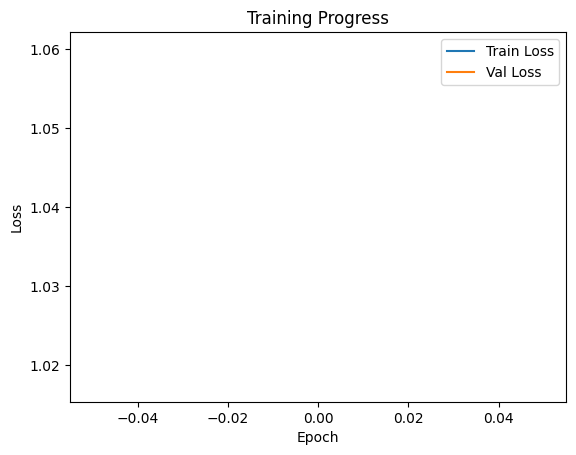


Epoch 2/20


Train Loss: 1.0029 | Train Acc: 0.6392
Val   Loss: 0.9593 | Val   Acc: 0.7419
✅ Best model updated


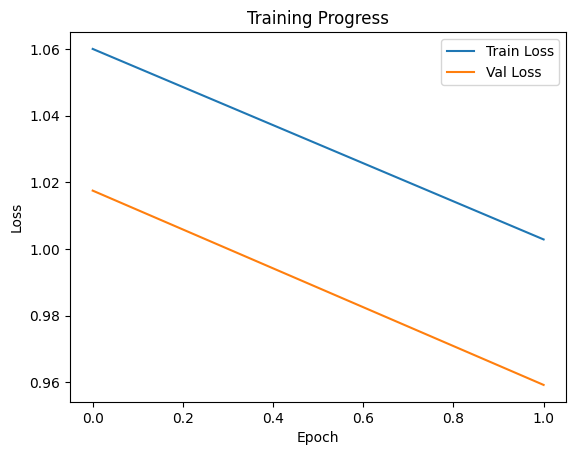


Epoch 3/20


Train Loss: 0.9691 | Train Acc: 0.6926
Val   Loss: 0.9253 | Val   Acc: 0.8011
✅ Best model updated


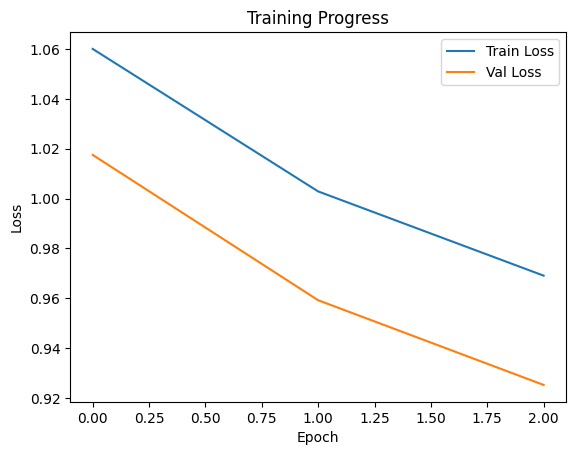


Epoch 4/20
🚀 Unfreezing backbone...


Train Loss: 0.9569 | Train Acc: 0.6963
Val   Loss: 0.9132 | Val   Acc: 0.8065
✅ Best model updated


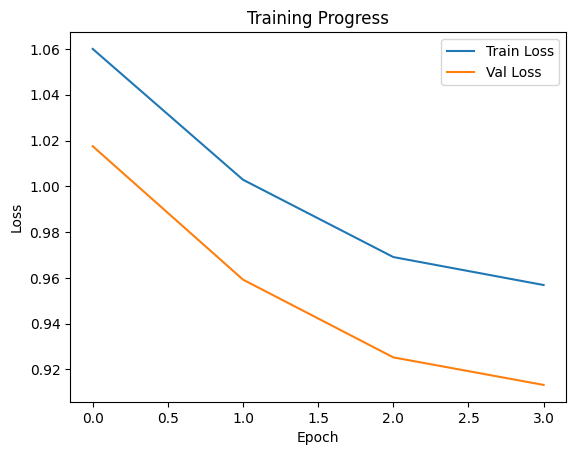


Epoch 5/20


Train Loss: 0.9500 | Train Acc: 0.7049
Val   Loss: 0.9051 | Val   Acc: 0.8065
✅ Best model updated


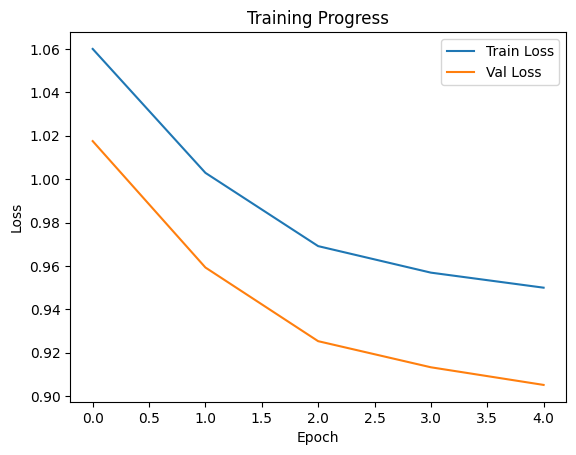


Epoch 6/20


Train Loss: 0.9436 | Train Acc: 0.7091
Val   Loss: 0.9018 | Val   Acc: 0.7849
✅ Best model updated


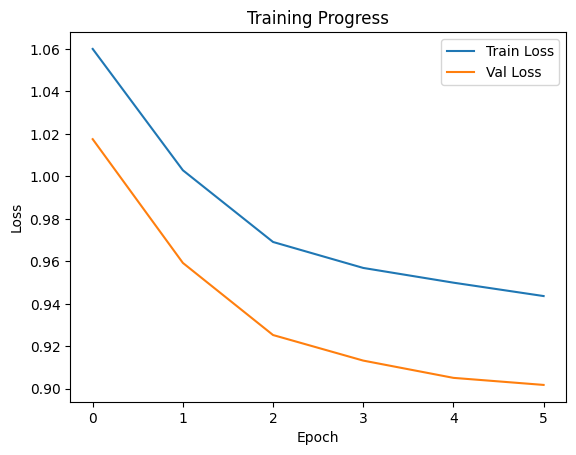


Epoch 7/20


Train Loss: 0.9427 | Train Acc: 0.7057
Val   Loss: 0.9002 | Val   Acc: 0.7957
✅ Best model updated


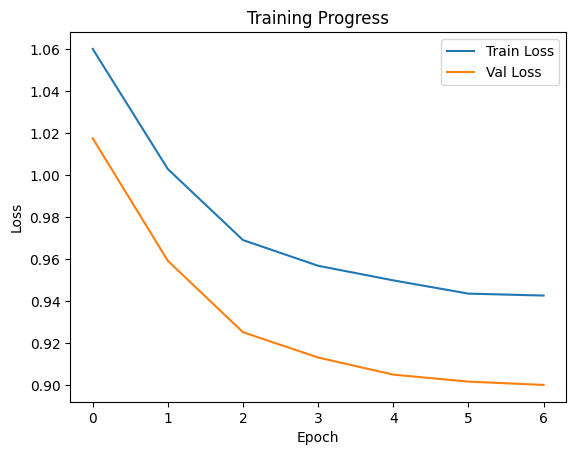


Epoch 8/20


Train Loss: 0.9449 | Train Acc: 0.7049
Val   Loss: 0.8997 | Val   Acc: 0.7903
✅ Best model updated


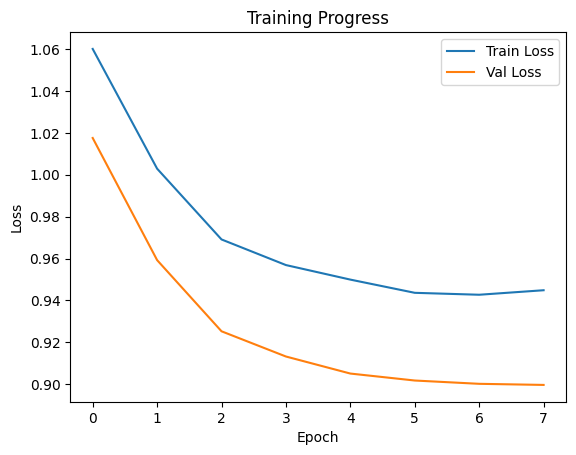


Epoch 9/20


Train Loss: 0.9428 | Train Acc: 0.7038
Val   Loss: 0.8972 | Val   Acc: 0.7849
✅ Best model updated


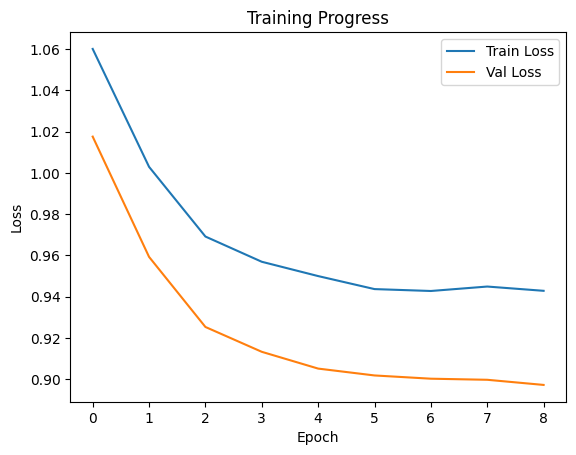


Epoch 10/20


Train Loss: 0.9438 | Train Acc: 0.7117
Val   Loss: 0.8981 | Val   Acc: 0.7849
⚠️ No improvement for 1 epochs


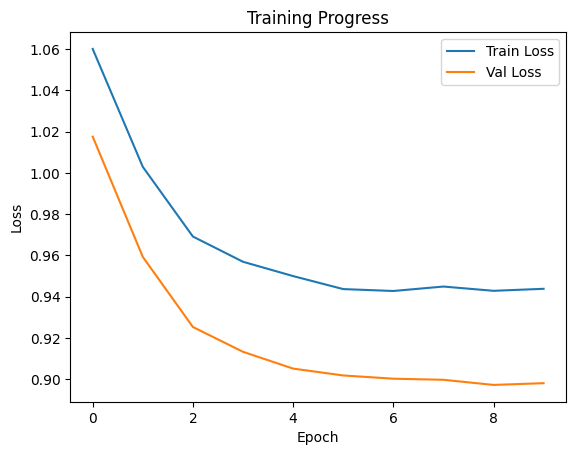


Epoch 11/20


Train Loss: 0.9473 | Train Acc: 0.7041
Val   Loss: 0.8989 | Val   Acc: 0.7903
⚠️ No improvement for 2 epochs


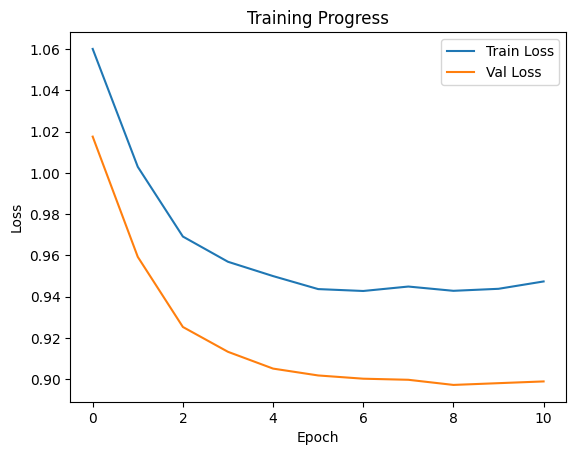


Epoch 12/20


Train Loss: 0.9480 | Train Acc: 0.7117
Val   Loss: 0.9002 | Val   Acc: 0.7957
⚠️ No improvement for 3 epochs


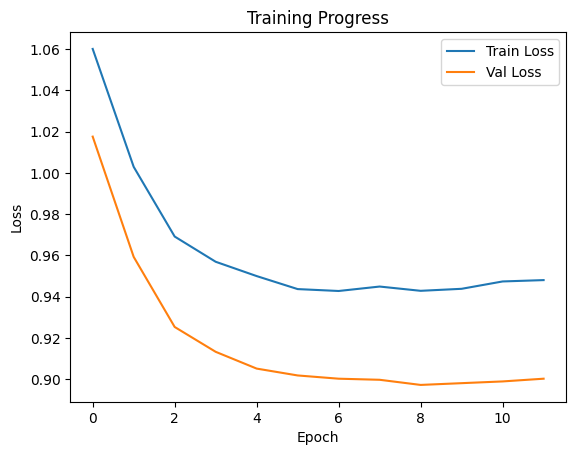


Epoch 13/20


Train Loss: 0.9500 | Train Acc: 0.7148
Val   Loss: 0.9004 | Val   Acc: 0.7796
⚠️ No improvement for 4 epochs
🛑 Early stopping triggered


In [11]:
plt.ion()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    if epoch == FREEZE_EPOCHS:
        print("🚀 Unfreezing backbone...")

        for param in model.features[-4:].parameters():
            param.requires_grad = True

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), 
            lr=1e-5,
            weight_decay=1e-4
        )

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=2, factor=0.3
        )

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # 🔥 EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print("✅ Best model updated")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epochs")

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered")
        break

    # 📊 LIVE GRAPH
    plt.clf()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Progress")
    plt.pause(0.1)

plt.ioff()
plt.show()

## Restore Best Weights and Evaluate

Restores the model state dict that achieved the lowest validation loss during training, then runs a single final evaluation on the held-out test set. The test set is touched only here — it was never used for training decisions or scheduler stepping.

In [12]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [13]:
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("\nTest Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")


Test Results:
Loss: 0.9407
Accuracy: 0.7219


### F1 Score

Weighted F1 accounts for class imbalance by averaging per-class F1 scores weighted by support (number of true instances per class). This is a more honest summary metric than accuracy for an imbalanced 3-class problem.

In [14]:
from sklearn.metrics import f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 🔥 F1 Score
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7213


In [15]:
torch.save(model.state_dict(), "ConvNeXt_pneumonia.pth")

import json
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)

### Classification Report

Per-class breakdown of precision, recall, and F1-score on the test set. This is more informative than overall accuracy for an imbalanced dataset — a model that always predicts `NORMAL` or `BACTERIAL_PNEUMONIA` could still score high accuracy while completely missing `VIRAL_PNEUMONIA`. The per-class recall column is especially important in a medical screening context where false negatives carry clinical risk.

In [16]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=prep.train_dataset.classes))

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.76      0.81      0.78       234
             NORMAL       0.75      0.65      0.70       227
    VIRAL_PNEUMONIA       0.63      0.69      0.66       143

           accuracy                           0.72       604
          macro avg       0.71      0.72      0.71       604
       weighted avg       0.72      0.72      0.72       604

